In [1]:
### Glory Onyeugbo, Amelia Green
### Purpose: Predict the MPAA Rating for "Shrek 2"


# Load the necessary packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
import nltk
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')
#print(stopwords.words('english'))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\glory\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\glory\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Import both datasets
imdb = pd.read_csv('IMDB_parental_guide2.csv')
#imdb['mpaa'] = imdb['mpaa'].astype('str').apply(lambda x: x.zfill(5))

movie_lens = pd.read_csv('movies_metadata.csv')
movie_lens['title'] = movie_lens['title'].astype('str').apply(lambda x: x.zfill(5))


C:\Users\glory\AppData\Local\Temp\ipykernel_5392\955520789.py:5: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movie_lens = pd.read_csv('movies_metadata.csv')


In [3]:
# Count the number of rows and columns in the imdb and movie data frames.
print('Number of rows in IMDB:', len(imdb))
print('Number of columns in IMDB:', len(imdb.columns))

print('Number of rows in Movie Lens:', len(movie_lens))
print('Number of columns in Movie Lens:', len(movie_lens.columns))

Number of rows in IMDB: 53228
Number of columns in IMDB: 22
Number of rows in Movie Lens: 45466
Number of columns in Movie Lens: 24


In [4]:
##########################################
# DATA CLEANING
##########################################

# Filtering rows where titleType is 'movie'. We only want to focus on movies for our analysis.
imdb_movies = imdb[imdb['titleType'] == 'movie']

# Remove unnecessay columns from both datasets
imdb_columns_to_drop = ['titleType','numVotes', 'certificate']
movie_lens_columns_to_drop = ['belongs_to_collection', 'budget', 'genres', 'homepage', 'original_title', 'poster_path'
                              , 'production_countries', 'revenue', 'spoken_languages', 'status', 'tagline', 'title'
                              , 'video', 'vote_average', 'vote_count']


imdb_movies.drop(columns = imdb_columns_to_drop, inplace = True)
movie_lens.drop(columns = movie_lens_columns_to_drop, inplace = True)


C:\Users\glory\AppData\Local\Temp\ipykernel_5392\2020668968.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_movies.drop(columns = imdb_columns_to_drop, inplace = True)


In [5]:
# Rename columns to readable texts
imdb_movies = imdb_movies.rename(columns = {'tconst':'imdbID'
                                   , 'primaryTitle': 'title'
                                   , 'runtimeMinutes' : 'runtime(mins.)'
                                   , 'mpaa':'mpaaRating'})


movie_lens = movie_lens.rename(columns = {'imdb_id': 'imdbID'
                                         , 'original_language': 'language'
                                         , 'release_Date': 'releaseDate'
                                         , 'production_companies': 'productionCompanies'})

In [6]:
print("Number of rows where 'mpaaRating' is empty:", len(imdb_movies[imdb_movies['mpaaRating'].isna() | (imdb_movies['mpaaRating'] == '')]))

Number of rows where 'mpaaRating' is empty: 26823


In [7]:
# Check for missing variables
print(imdb_movies.isna().sum())

print(movie_lens.isna().sum())

imdbID                0
title                 0
originalTitle         0
isAdult               0
startYear             0
runtime(mins.)        0
genres                0
averageRating         0
sex               20461
violence          17321
profanity         19549
drugs             18225
intense           19270
sex_code          10949
violence_code     13063
profanity_code    13819
drug_code         14105
intense_code      14434
mpaaRating        26823
dtype: int64
adult                    0
id                       0
imdbID                  17
language                11
overview               954
popularity               5
productionCompanies      3
release_date            87
runtime                263
dtype: int64


In [8]:
# Remove rows with missing data
movie_lens = movie_lens.dropna(subset=['imdbID'])
movie_lens = movie_lens.dropna(subset=['language'])

In [9]:
# Insert 0 for the NAs in sex, violence, profanity, drug, and intense codes

imdb_movies['sex_code'].fillna(0, inplace=True)
imdb_movies['violence_code'].fillna(0, inplace=True)
imdb_movies['profanity_code'].fillna(0, inplace=True)
imdb_movies['drug_code'].fillna(0, inplace=True)
imdb_movies['intense_code'].fillna(0, inplace=True)

print(imdb_movies.isna().sum())

imdbID                0
title                 0
originalTitle         0
isAdult               0
startYear             0
runtime(mins.)        0
genres                0
averageRating         0
sex               20461
violence          17321
profanity         19549
drugs             18225
intense           19270
sex_code              0
violence_code         0
profanity_code        0
drug_code             0
intense_code          0
mpaaRating        26823
dtype: int64


In [10]:
# What are the types of data in both datasets?
print(imdb_movies.dtypes)
print(movie_lens.dtypes)

imdbID             object
title              object
originalTitle      object
isAdult             int64
startYear           int64
runtime(mins.)    float64
genres             object
averageRating     float64
sex                object
violence           object
profanity          object
drugs              object
intense            object
sex_code          float64
violence_code     float64
profanity_code    float64
drug_code         float64
intense_code      float64
mpaaRating         object
dtype: object
adult                   object
id                      object
imdbID                  object
language                object
overview                object
popularity              object
productionCompanies     object
release_date            object
runtime                float64
dtype: object


In [11]:
# Make popularity in movie_lens data numeric.
movie_lens['popularity'] = pd.to_numeric(movie_lens['popularity'], errors='coerce')

# Check the datatype after conversion
print(movie_lens['popularity'].dtype)

float64


In [12]:
# Change the language codes to their full names for better readability

# Filter out rows where 'language' values are numeric
movie_lens = movie_lens[~movie_lens['language'].str.isnumeric()]

# Define a mapping from language codes to full names
language_mapping = {
    'ab': 'Abkhazian',
    'af': 'Afrikaans',
    'am': 'Amharic',
    'ar': 'Arabic',
    'ay': 'Aymara',
    'bg': 'Bulgarian',
    'bn': 'Bengali',
    'bo': 'Tibetan',
    'bs': 'Bosnian',
    'ca': 'Catalan',
    'cs': 'Czech',
    'cy': 'Welsh',
    'da': 'Danish',
    'de': 'German',
    'el': 'Greek',
    'en': 'English',
    'es': 'Spanish',
    'et': 'Estonian',
    'eu': 'Basque',
    'fa': 'Persian',
    'fi': 'Finnish',
    'fr': 'French',
    'fy': 'Frisian',
    'gl': 'Galician',
    'he': 'Hebrew',
    'hi': 'Hindi',
    'hr': 'Croatian',
    'hu': 'Hungarian',
    'hy': 'Armenian',
    'id': 'Indonesian',
    'is': 'Icelandic',
    'it': 'Italian',
    'ja': 'Japanese',
    'jv': 'Javanese',
    'ka': 'Georgian',
    'kk': 'Kazakh',
    'kn': 'Kannada',
    'ko': 'Korean',
    'ku': 'Kurdish',
    'ky': 'Kyrgyz',
    'la': 'Latin',
    'lb': 'Luxembourgish',
    'lo': 'Lao',
    'lt': 'Lithuanian',
    'lv': 'Latvian',
    'mk': 'Macedonian',
    'ml': 'Malayalam',
    'mn': 'Mongolian',
    'mr': 'Marathi',
    'ms': 'Malay',
    'mt': 'Maltese',
    'nb': 'Norwegian Bokmål',
    'ne': 'Nepali',
    'nl': 'Dutch',
    'no': 'Norwegian',
    'pa': 'Punjabi',
    'pl': 'Polish',
    'ps': 'Pashto',
    'pt': 'Portuguese',
    'qu': 'Quechua',
    'ro': 'Romanian',
    'ru': 'Russian',
    'rw': 'Kinyarwanda',
    'sh': 'Serbo-Croatian',
    'si': 'Sinhalese',
    'sk': 'Slovak',
    'sl': 'Slovenian',
    'sm': 'Samoan',
    'sq': 'Albanian',
    'sr': 'Serbian',
    'sv': 'Swedish',
    'ta': 'Tamil',
    'te': 'Telugu',
    'tg': 'Tajik',
    'th': 'Thai',
    'tl': 'Tagalog',
    'tr': 'Turkish',
    'uk': 'Ukrainian',
    'ur': 'Urdu',
    'uz': 'Uzbek',
    'vi': 'Vietnamese',
    'wo': 'Wolof',
    'zh': 'Chinese',
    'zu': 'Zulu',
}


# Replace language codes with full names
movie_lens['language'] = movie_lens['language'].map(language_mapping)

# Convert 'language' column to a categorical type
movie_lens['language'] = movie_lens['language'].astype('category')

# Print the updated levels (categories) of the 'language' column
print("Updated Levels (categories) of the 'language' column:")
print(movie_lens['language'].cat.categories)

Updated Levels (categories) of the 'language' column:
Index(['Abkhazian', 'Afrikaans', 'Albanian', 'Amharic', 'Arabic', 'Armenian',
       'Aymara', 'Basque', 'Bengali', 'Bosnian', 'Bulgarian', 'Catalan',
       'Chinese', 'Croatian', 'Czech', 'Danish', 'Dutch', 'English',
       'Estonian', 'Finnish', 'French', 'Frisian', 'Galician', 'Georgian',
       'German', 'Greek', 'Hebrew', 'Hindi', 'Hungarian', 'Icelandic',
       'Indonesian', 'Italian', 'Japanese', 'Javanese', 'Kannada', 'Kazakh',
       'Kinyarwanda', 'Korean', 'Kurdish', 'Kyrgyz', 'Lao', 'Latin', 'Latvian',
       'Lithuanian', 'Luxembourgish', 'Macedonian', 'Malay', 'Malayalam',
       'Maltese', 'Marathi', 'Mongolian', 'Nepali', 'Norwegian',
       'Norwegian Bokmål', 'Pashto', 'Persian', 'Polish', 'Portuguese',
       'Punjabi', 'Quechua', 'Romanian', 'Russian', 'Samoan', 'Serbian',
       'Serbo-Croatian', 'Sinhalese', 'Slovak', 'Slovenian', 'Spanish',
       'Swedish', 'Tagalog', 'Tajik', 'Tamil', 'Telugu', 'Thai', 'T

In [13]:
imdb_movies['mpaaRatingWords'] = imdb_movies['mpaaRating']

print(imdb_movies['mpaaRatingWords'].head())



0             Rated R for language and prison violence
1    Rated PG-13 for intense sequences of violence ...
2    Rated PG-13 for sequences of violence and acti...
3    Rated R for disturbing and graphic depiction o...
5    Rated PG-13 for drug content, some sensuality ...
Name: mpaaRatingWords, dtype: object


In [14]:
from nltk.corpus import stopwords  
from nltk.tokenize import word_tokenize 

stop_words = set(stopwords.words('english'))  
#stop_words = nltk.corpus.stopwords.words('english')
#stop_words.append('00nan')


#def remove_stopwords(sentence):
#    word_tokens = word_tokenize(sentence)      
#    clean_tokens = [w for w in word_tokens if not w in stop_words]  
    
#    return clean_tokens
    
# imdb_movies['mpaaRatingWords'] = imdb_movies['mpaaRatingWords'].apply(remove_stopwords)




# Define function to remove stopwords
def remove_stopwords(sentence):
    if pd.isnull(sentence):
        return ""
    else:
        word_tokens = word_tokenize(sentence)
        clean_tokens = [w for w in word_tokens if not w in stop_words]
        return clean_tokens

# Fill NA values with an empty string in the 'mpaaRatingWords' column
imdb_movies['mpaaRatingWords'].fillna("", inplace=True)

# Apply remove_stopwords function to 'mpaaRatingWords' column
imdb_movies['mpaaRatingWords'] = imdb_movies['mpaaRatingWords'].apply(remove_stopwords)

In [15]:
#### Extracting mpaa Rating ####
# Remove special characters and spaces from the 'mpaaRating' column
imdb_movies['mpaaRating'] = imdb_movies['mpaaRating'].str.replace(r'[^a-zA-Z0-9\s]', '').str.strip()

# Display the updated dataframe
print(imdb_movies[['mpaaRating']])

                                              mpaaRating
0               Rated R for language and prison violence
1      Rated PG-13 for intense sequences of violence ...
2      Rated PG-13 for sequences of violence and acti...
3      Rated R for disturbing and graphic depiction o...
5      Rated PG-13 for drug content, some sensuality ...
...                                                  ...
53221                                                NaN
53224                                                NaN
53225                                                NaN
53226                                            Rated R
53227                                                NaN

[39124 rows x 1 columns]


In [16]:
# Extracting rating from MPAA string
imdb_movies['mpaaRating'] = imdb_movies['mpaaRating'].str.split(' ', expand = True)[1]
# imdb_movies.loc[imdb_movies['mpaaRating'] != 'Unrated', 'mpaaRating'] = imdb_movies.loc[imdb_movies['mpaaRating'] != 'Unrated', 'mpaaRating'].str.split(' ', expand=True)[1]

print("TOP 20:")
print(imdb_movies['mpaaRating'].head(20))

print("BOTTOM 20:")
print(imdb_movies['mpaaRating'].tail(20))

TOP 20:
0         R
1     PG-13
2     PG-13
3         R
5     PG-13
6         R
7         R
9     PG-13
10        R
11    PG-13
12    PG-13
13    PG-13
14    PG-13
15        R
16        R
17        R
18    PG-13
19        R
20        R
21        R
Name: mpaaRating, dtype: object
BOTTOM 20:
53200    NaN
53201      R
53203     PG
53204     NR
53205     NR
53206    NaN
53207    NaN
53209     PG
53210      R
53211    NaN
53212    NaN
53213    NaN
53215    NaN
53216    NaN
53217    NaN
53221    NaN
53224    NaN
53225    NaN
53226      R
53227    NaN
Name: mpaaRating, dtype: object


In [17]:
# Print the unique values in the 'mpaaRating' column
print(imdb_movies['mpaaRating'].unique())

['R' 'PG-13' 'PG' 'G' nan 'G\xa0for' 'NC-17' None 'NR']


In [18]:
# Get unique values in the 'mpaaRating' column
mpaa_ratings = imdb_movies['mpaaRating'].unique()

# Preprocess the values to remove any special characters or whitespace
mpaa_ratings_cleaned = [rating.strip() for rating in mpaa_ratings if isinstance(rating, str)]

# Print the cleaned unique MPAA ratings
print(mpaa_ratings_cleaned)

['R', 'PG-13', 'PG', 'G', 'G\xa0for', 'NC-17', 'NR']


In [19]:
imdb_movies['totalScore'] = imdb_movies['sex_code'] + imdb_movies['violence_code'] + imdb_movies['profanity_code'] + imdb_movies['drug_code'] + imdb_movies['intense_code']
imdb_movies.head()

,imdbID,title,originalTitle,isAdult,startYear,runtime(mins.),genres,averageRating,sex,violence,...,drugs,intense,sex_code,violence_code,profanity_code,drug_code,intense_code,mpaaRating,mpaaRatingWords,totalScore
0,tt0111161,The Shawshank Redemption,The Shawshank Redemption,0,1994,142.0,Drama,9.3,Mild,Moderate,...,Mild,Moderate,2.0,3.0,4.0,2.0,3.0,R,"[Rated, R, language, prison, violence]",14.0
1,tt0468569,The Dark Knight,The Dark Knight,0,2008,152.0,"Action,Crime,Drama",9.0,NaN,Moderate,...,Mild,Severe,1.0,3.0,2.0,2.0,4.0,PG-13,"[Rated, PG-13, intense, sequences, violence, m...",12.0
2,tt1375666,Inception,Inception,0,2010,148.0,"Action,Adventure,Sci-Fi",8.8,NaN,Moderate,...,Mild,Moderate,1.0,3.0,2.0,2.0,3.0,PG-13,"[Rated, PG-13, sequences, violence, action, th...",11.0
3,tt0137523,Fight Club,Fight Club,0,1999,139.0,Drama,8.8,Moderate,Severe,...,Moderate,Severe,3.0,4.0,4.0,3.0,4.0,R,"[Rated, R, disturbing, graphic, depiction, vio...",18.0
5,tt0109830,Forrest Gump,Forrest Gump,0,1994,142.0,"Drama,Romance",8.8,Moderate,Moderate,...,Moderate,Moderate,3.0,3.0,3.0,3.0,3.0,PG-13,"[Rated, PG-13, drug, content, ,, sensuality, w...",15.0


In [20]:
grouped = imdb_movies.groupby('mpaaRating')[['sex_code', 'violence_code', 'profanity_code', 'drug_code', 'totalScore']].mean()
grouped

,sex_code,violence_code,profanity_code,drug_code,totalScore
mpaaRating,,,,,
G,1.135135,1.756757,1.000000,1.324324,7.189189
G for,1.000000,1.000000,1.000000,1.000000,6.000000
NC-17,3.700000,2.950000,3.200000,2.700000,15.450000
NR,0.500000,0.000000,0.000000,0.000000,0.500000
PG,1.183769,1.541918,1.362173,1.300469,6.974514
PG-13,1.599376,1.900780,1.901404,1.617473,8.828393
R,2.078979,2.451935,2.547667,1.955325,11.189868


In [21]:
# Define the ranges for buckets
ranges = [1, 8.3, 10.34, 13.34, 15.44, float('inf')]

# Define the labels for buckets
labels = ['G', 'PG', 'PG-13', 'R', 'NC-17']

# Create a new column 'rating_bucket' based on totalScore ranges
grouped['rating_bucket'] = pd.cut(grouped['totalScore'], bins=ranges, labels=labels)

# Print the result
print(grouped[['totalScore', 'rating_bucket']])

            totalScore rating_bucket
mpaaRating                          
G             7.189189             G
G for         6.000000             G
NC-17        15.450000         NC-17
NR            0.500000           NaN
PG            6.974514             G
PG-13         8.828393            PG
R            11.189868         PG-13


In [22]:
# Conditionally assign MPAA ratings based on totalScore and existing MPAA ratings
imdb_movies.loc[(imdb_movies['mpaaRating'].isnull()) & (imdb_movies['totalScore'] >= 1) & (imdb_movies['totalScore'] < 8.376501), 'mpaaRating'] = 'G'
imdb_movies.loc[(imdb_movies['mpaaRating'].isnull()) & (imdb_movies['totalScore'] < 10.355206), 'mpaaRating'] = 'PG'
imdb_movies.loc[(imdb_movies['mpaaRating'].isnull()) & (imdb_movies['totalScore'] < 13.351589), 'mpaaRating'] = 'PG-13'
imdb_movies.loc[(imdb_movies['mpaaRating'].isnull()) & (imdb_movies['totalScore'] < 15.450000), 'mpaaRating'] = 'R'
imdb_movies.loc[imdb_movies['mpaaRating'].isnull() & (imdb_movies['totalScore'] >= 15.450000), 'mpaaRating'] = 'NC-17'
imdb_movies.loc[imdb_movies['mpaaRating'].isnull(), 'mpaaRating'] = 'NR'                                                      



print("TOP 20:")
print(imdb_movies['mpaaRating'].head(20))

print("/BOTTOM 20:")
print(imdb_movies['mpaaRating'].tail(20))

TOP 20:
0         R
1     PG-13
2     PG-13
3         R
5     PG-13
6         R
7         R
9     PG-13
10        R
11    PG-13
12    PG-13
13    PG-13
14    PG-13
15        R
16        R
17        R
18    PG-13
19        R
20        R
21        R
Name: mpaaRating, dtype: object
/BOTTOM 20:
53200       PG
53201        R
53203       PG
53204       NR
53205       NR
53206        G
53207       PG
53209       PG
53210        R
53211    PG-13
53212       PG
53213       PG
53215       PG
53216       PG
53217    PG-13
53221        G
53224       PG
53225        G
53226        R
53227       PG
Name: mpaaRating, dtype: object


In [23]:
############################## CLEANING MOVIE LENS DATA ##############################

# We want to extract production company names from a list
movie_lens['productionCompanies'] = movie_lens['productionCompanies'].apply(lambda x: eval(x) if isinstance(x, str) else x)

# Extract production company names
movie_lens['productionCompaniesNames'] = movie_lens['productionCompanies'].apply(lambda companies: [company['name'] for company in companies] if isinstance(companies, list) else [])

# If you want a single string instead of a list for movies with multiple companies
movie_lens['productionCompaniesNames'] = movie_lens['productionCompanies'].apply(lambda companies: ', '.join([company['name'] for company in companies]) if isinstance(companies, list) else '')

# Display the DataFrame to verify the changes
print(movie_lens[['productionCompanies', 'productionCompaniesNames']])

                                     productionCompanies  \
0         [{'name': 'Pixar Animation Studios', 'id': 3}]   
1      [{'name': 'TriStar Pictures', 'id': 559}, {'na...   
2      [{'name': 'Warner Bros.', 'id': 6194}, {'name'...   
3      [{'name': 'Twentieth Century Fox Film Corporat...   
4      [{'name': 'Sandollar Productions', 'id': 5842}...   
...                                                  ...   
45461                                                 []   
45462             [{'name': 'Sine Olivia', 'id': 19653}]   
45463  [{'name': 'American World Pictures', 'id': 6165}]   
45464               [{'name': 'Yermoliev', 'id': 88753}]   
45465                                                 []   

                                productionCompaniesNames  
0                                Pixar Animation Studios  
1      TriStar Pictures, Teitler Film, Interscope Com...  
2                           Warner Bros., Lancaster Gate  
3                 Twentieth Century Fox Fil

In [24]:
########################################### MERGING DATA SETS #################################################
# Merge dataframes based on 'imdb_id'
movies_df = pd.merge(imdb_movies, movie_lens, on = 'imdbID', how = 'inner')

# Display the combined dataframe
print(movies_df)

          imdbID                               title  \
0      tt0111161            The Shawshank Redemption   
1      tt0468569                     The Dark Knight   
2      tt1375666                           Inception   
3      tt0137523                          Fight Club   
4      tt0109830                        Forrest Gump   
...          ...                                 ...   
26177  tt0043079                      Two Flags West   
26178  tt0043828                   My Forbidden Past   
26179  tt0073878       W.W. and the Dixie Dancekings   
26180  tt0129222  The Man Who Had His Hair Cut Short   
26181  tt0214931                                Mast   

                                originalTitle  isAdult  startYear  \
0                    The Shawshank Redemption        0       1994   
1                             The Dark Knight        0       2008   
2                                   Inception        0       2010   
3                                  Fight Club      

In [25]:
movies_df_columns_to_drop = ['originalTitle', 'id', 'productionCompanies']


movies_df.drop(columns = movies_df_columns_to_drop, inplace = True)

movies_df.head()

,imdbID,title,isAdult,startYear,runtime(mins.),genres,averageRating,sex,violence,profanity,...,mpaaRating,mpaaRatingWords,totalScore,adult,language,overview,popularity,release_date,runtime,productionCompaniesNames
0,tt0111161,The Shawshank Redemption,0,1994,142.0,Drama,9.3,Mild,Moderate,Severe,...,R,"[Rated, R, language, prison, violence]",14.0,False,English,Framed in the 1940s for the double murder of h...,51.645403,1994-09-23,142.0,"Castle Rock Entertainment, Warner Bros."
1,tt0468569,The Dark Knight,0,2008,152.0,"Action,Crime,Drama",9.0,NaN,Moderate,Mild,...,PG-13,"[Rated, PG-13, intense, sequences, violence, m...",12.0,False,English,Batman raises the stakes in his war on crime. ...,123.167259,2008-07-16,152.0,"DC Comics, Legendary Pictures, Warner Bros., D..."
2,tt1375666,Inception,0,2010,148.0,"Action,Adventure,Sci-Fi",8.8,NaN,Moderate,Mild,...,PG-13,"[Rated, PG-13, sequences, violence, action, th...",11.0,False,English,"Cobb, a skilled thief who commits corporate es...",29.108149,2010-07-14,148.0,"Legendary Pictures, Warner Bros., Syncopy"
3,tt0137523,Fight Club,0,1999,139.0,Drama,8.8,Moderate,Severe,Severe,...,R,"[Rated, R, disturbing, graphic, depiction, vio...",18.0,False,English,A ticking-time-bomb insomniac and a slippery s...,63.869599,1999-10-15,139.0,"Twentieth Century Fox Film Corporation, Regenc..."
4,tt0109830,Forrest Gump,0,1994,142.0,"Drama,Romance",8.8,Moderate,Moderate,Moderate,...,PG-13,"[Rated, PG-13, drug, content, ,, sensuality, w...",15.0,False,English,A man with a low IQ has accomplished great thi...,48.307194,1994-07-06,142.0,Paramount Pictures


In [26]:
print('Number of rows in Movie Lens:', len(movies_df))
print('Number of columns in Movie Lens:', len(movies_df.columns))

Number of rows in Movie Lens: 26182
Number of columns in Movie Lens: 27


In [27]:
# Print the row for Shrek 2 

shrek_2_row = movies_df[movies_df['title'] == 'Shrek 2']

# Print the row where title is 'Shrek 2'
print(shrek_2_row)

        imdbID    title  isAdult  startYear  runtime(mins.)  \
287  tt0298148  Shrek 2        0       2004            93.0   

                         genres  averageRating   sex violence profanity  ...  \
287  Adventure,Animation,Comedy            7.3  Mild     Mild      Mild  ...   

    mpaaRating                                    mpaaRatingWords  totalScore  \
287         PG  [Rated, PG, crude, humor, ,, brief, substance,...        10.0   

     adult  language                                           overview  \
287  False   English  Shrek, Fiona and Donkey set off to Far, Far Aw...   

     popularity release_date runtime  \
287    16.22986   2004-05-19    93.0   

                              productionCompaniesNames  
287  DreamWorks SKG, Pacific Data Images (PDI), Dre...  

[1 rows x 27 columns]


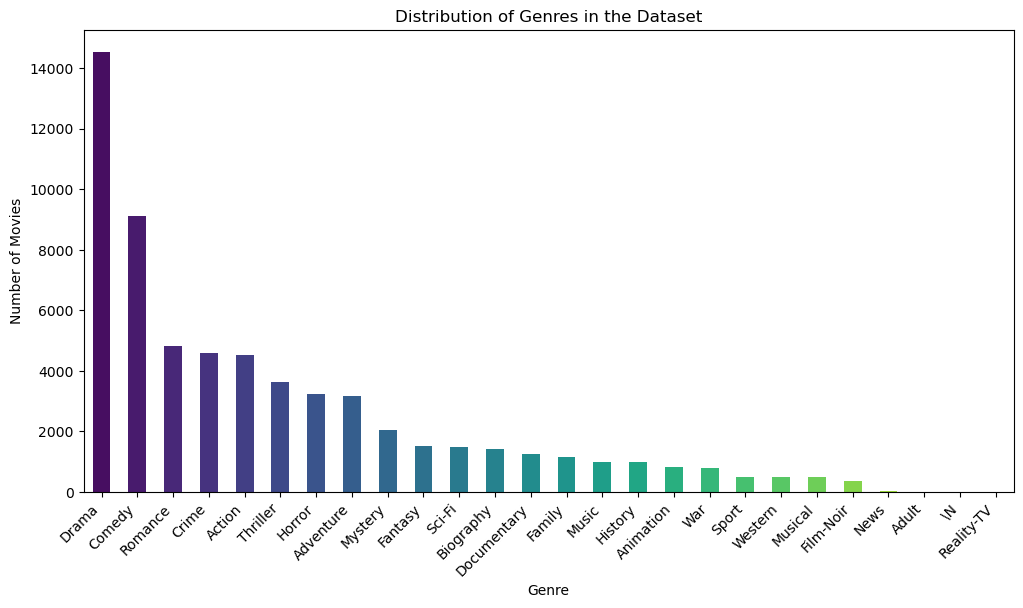

In [28]:
############################################# EXPLORATORY DATA ANALYSIS #############################################

#############################
# GENRE ANALYSIS
#############################

#### Explore the distribution of genres in the dataset ###

# Create a new dataframe to handle multiple genres
genres_df = movies_df['genres'].str.split(',', expand=True)

# Reshape the dataframe to have a single column for genres
genres_long = genres_df.melt(value_name='genre').dropna()['genre']

# Count the occurrences of each genre
genre_counts = genres_long.value_counts().sort_values(ascending=False)

# Set up a color palette
colors = sns.color_palette("viridis", len(genre_counts))

# Plot the distribution of genres with different colors
plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color=colors)
plt.title('Distribution of Genres in the Dataset')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.show()

In [29]:
### Analyze the average ratings and popularity for different genres. ###

# Create a new dataframe to handle multiple genres
#genres_df = movies_df['genres'].str.split(',', expand=True)

# Reshape the dataframe to have a single column for genres
#genres_long = genres_df.melt(value_name='genre').dropna()['genre']

# Merge the genres with the original dataframe
#movies_genre_merged = pd.concat([movies_df, genres_long], axis=1)

# Convert 'popularity' column to numeric
#movies_genre_merged['popularity'] = pd.to_numeric(movies_genre_merged['popularity'], errors='coerce')

# Plot average ratings and popularity for different genres with hue
#plt.figure(figsize=(14, 8))
#sns.barplot(x='genre', y='averageRating', hue='popularity', data=movies_genre_merged, estimator=np.mean, ci=None, palette='viridis')
#plt.title('Average Ratings and Popularity for Different Genres')
#plt.xlabel('Genre')
#plt.ylabel('Average Rating')
#plt.xticks(rotation=45, ha='right')
#plt.legend(title='Popularity')
#plt.show()

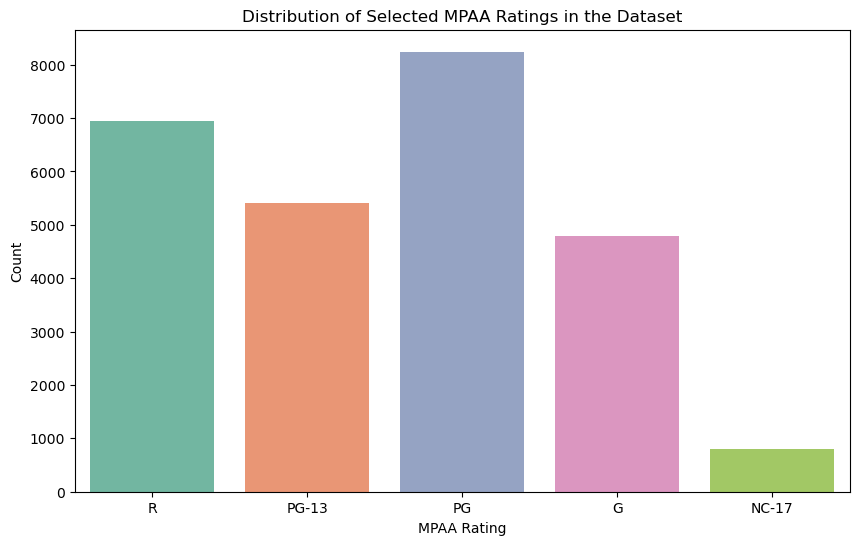

In [30]:
#############################
# MPAA RATING DISTRIBUTION
#############################

### Examine the distribution of MPAA ratings ('mpaaRating') in the dataset. ###
# List of selected MPAA ratings
selected_ratings = ['R', 'PG-13', 'PG', 'G', 'NC-17']

# Filter dataframe for selected ratings
filtered_df = movies_df[movies_df['mpaaRating'].isin(selected_ratings)]

# Plot the distribution of selected MPAA ratings
plt.figure(figsize=(10, 6))
sns.countplot(x = 'mpaaRating', data = movies_df, palette='Set2', order=selected_ratings)
plt.title('Distribution of Selected MPAA Ratings in the Dataset')
plt.xlabel('MPAA Rating')
plt.ylabel('Count')
plt.show()

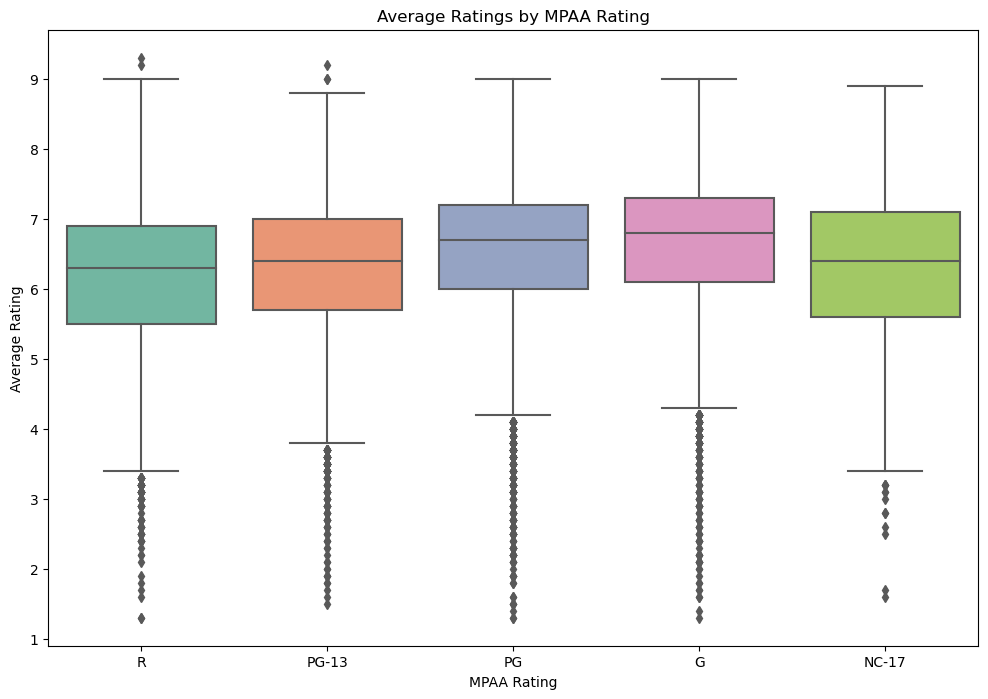

In [31]:
### Investigate the relationship between MPAA ratings and average ratings or popularity. ###
# Filter dataframe for selected MPAA ratings
selected_ratings = ['R', 'PG-13', 'PG', 'G', 'NC-17']
filtered_df = movies_df[movies_df['mpaaRating'].isin(selected_ratings)]

# Plot box plots for average ratings by MPAA rating
plt.figure(figsize=(12, 8))
sns.boxplot(x='mpaaRating', y='averageRating', data=filtered_df, palette='Set2', order=selected_ratings)
plt.title('Average Ratings by MPAA Rating')
plt.xlabel('MPAA Rating')
plt.ylabel('Average Rating')
plt.show()

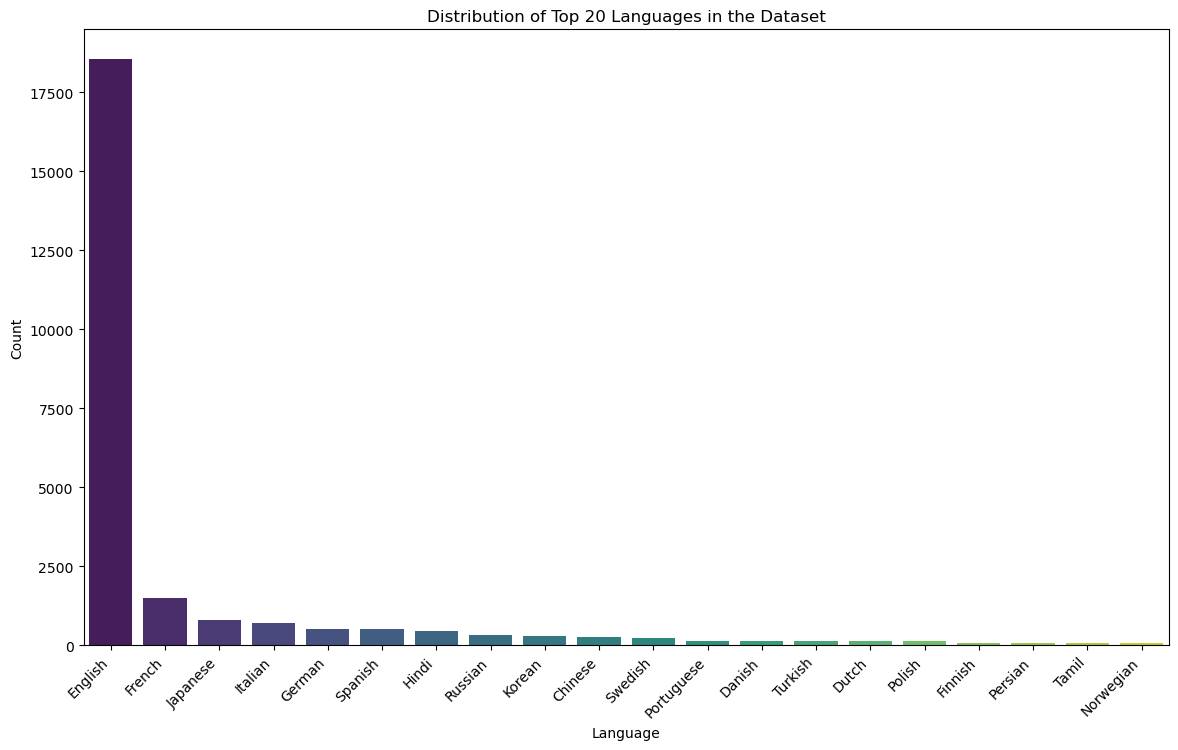

In [32]:
#############################
# LANGUAGE DISTRIBUTION
#############################

### Explore the distribution of languages ('language') in the dataset. ###

# Get the top 20 languages
top_languages = movies_df['language'].value_counts().nlargest(20).index

# Filter dataframe for the top 20 languages
filtered_df = movies_df[movies_df['language'].isin(top_languages)]

# Plot the distribution of the top 20 languages
plt.figure(figsize=(14, 8))
sns.countplot(x='language', data=filtered_df, palette='viridis', order=top_languages)
plt.title('Distribution of Top 20 Languages in the Dataset')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.show()

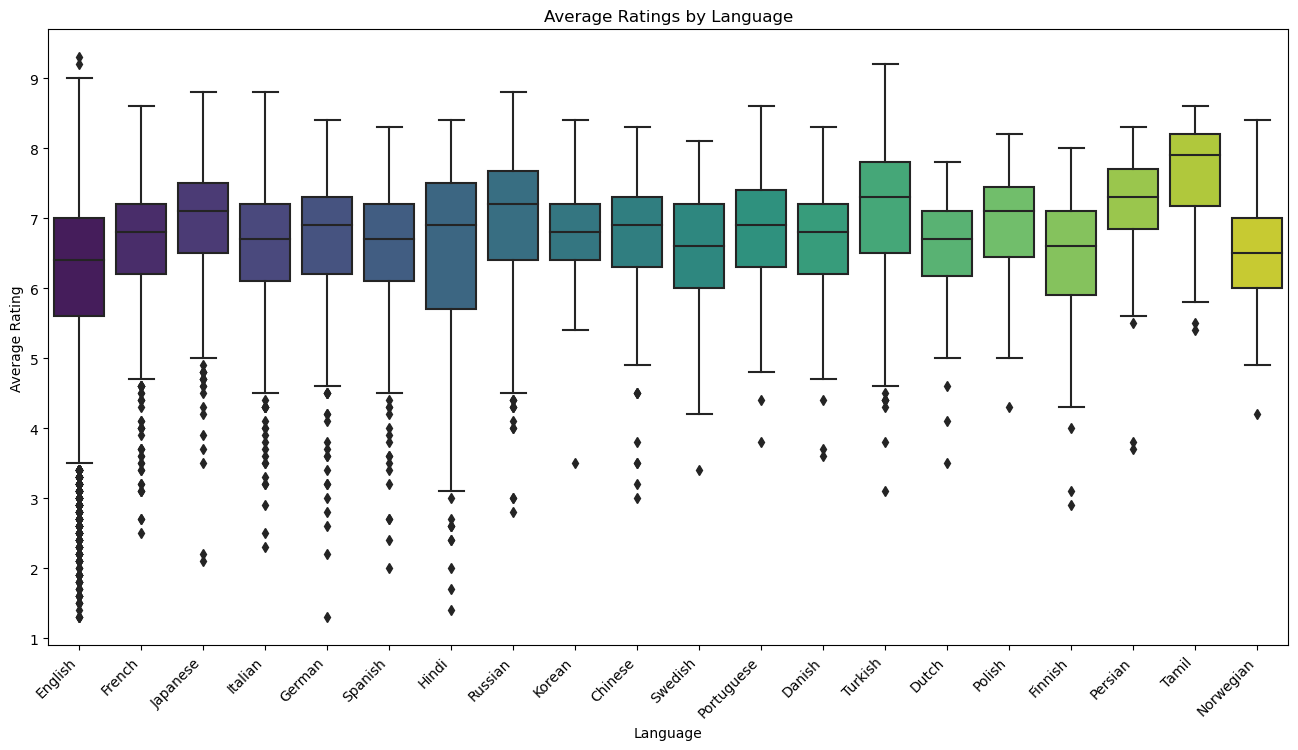

In [33]:
### Analyze how the language of a movie may impact its average rating or popularity. ###
# Filter dataframe for the top 20 languages
top_languages = movies_df['language'].value_counts().nlargest(20).index
filtered_df = movies_df[movies_df['language'].isin(top_languages)]

# Plot box plots for average ratings by language
plt.figure(figsize=(16, 8))
sns.boxplot(x='language', y='averageRating', data=filtered_df, palette='viridis', order=top_languages)
plt.title('Average Ratings by Language')
plt.xlabel('Language')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.show()

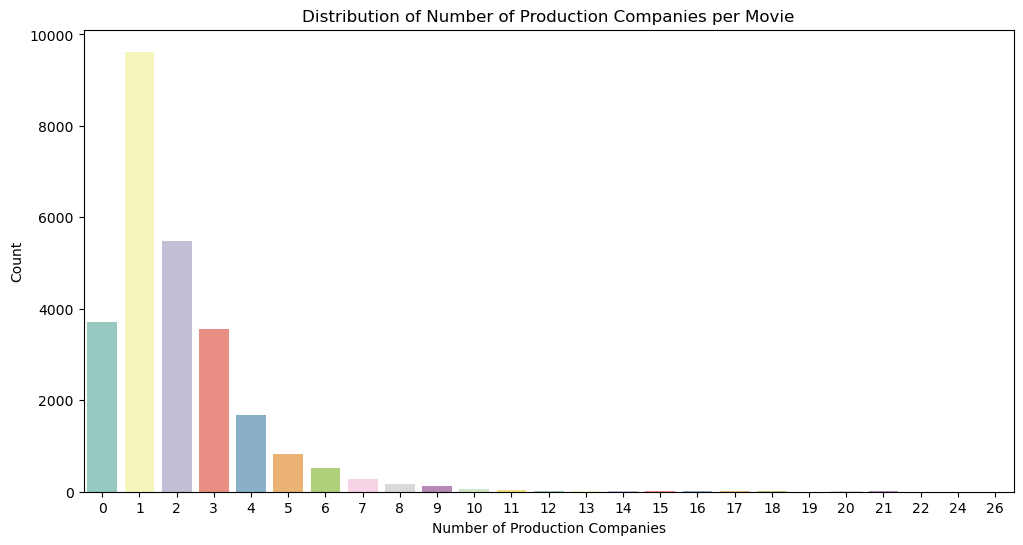

In [34]:
### Production Companies Analysis ###

### Explore the distribution of production companies.
# Extract the number of production companies per movie
movies_df['num_production_companies'] = movies_df['productionCompaniesNames'].apply(lambda x: len(x.split(',')) if x else 0)

# Plot the distribution of the number of production companies per movie
plt.figure(figsize=(12, 6))
sns.countplot(x='num_production_companies', data=movies_df, palette='Set3')
plt.title('Distribution of Number of Production Companies per Movie')
plt.xlabel('Number of Production Companies')
plt.ylabel('Count')
plt.show()

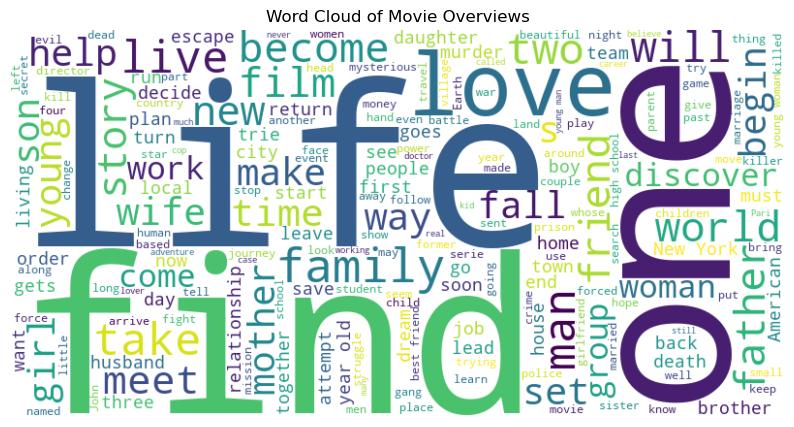

In [35]:
############################################### WORD CLOUDS ############################################

##### OVERVIEWS #####
# Combine all overviews into a single string
all_overviews = ' '.join(movies_df['overview'].dropna())

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_overviews)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud of Movie Overviews')
plt.axis('off')
plt.show()

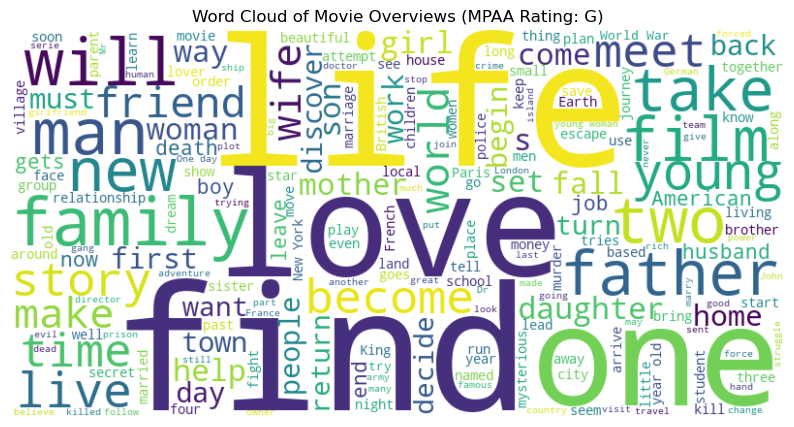

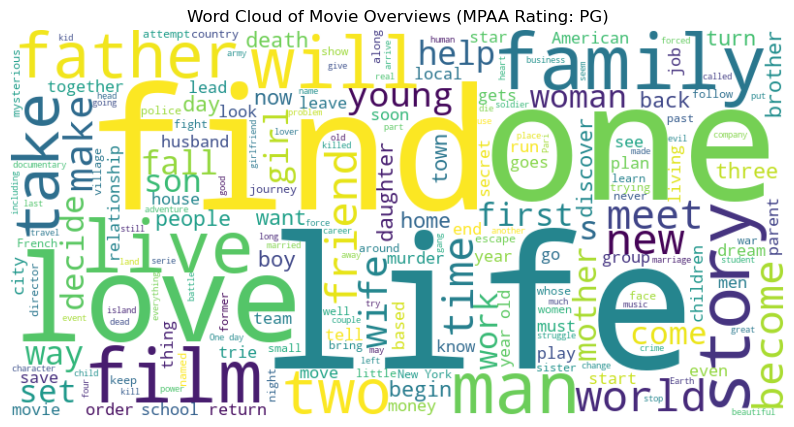

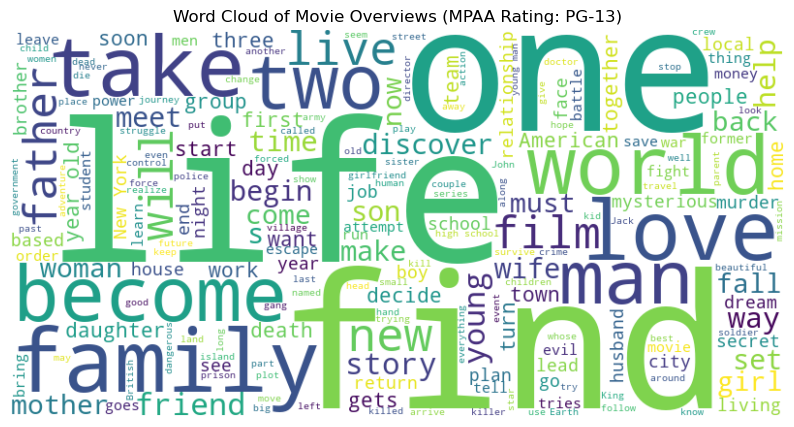

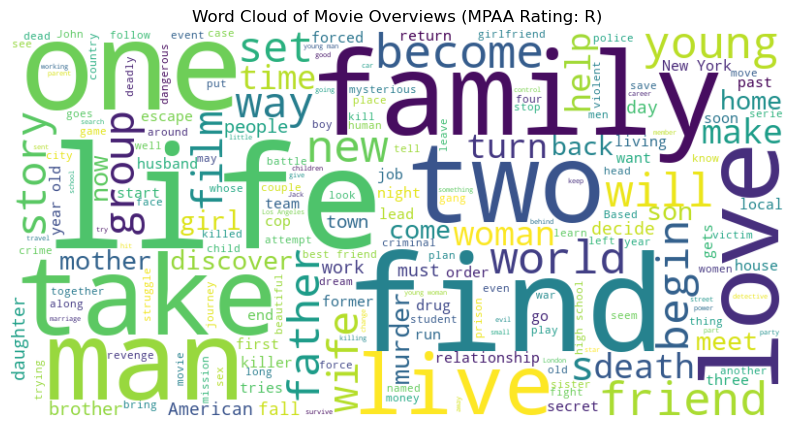

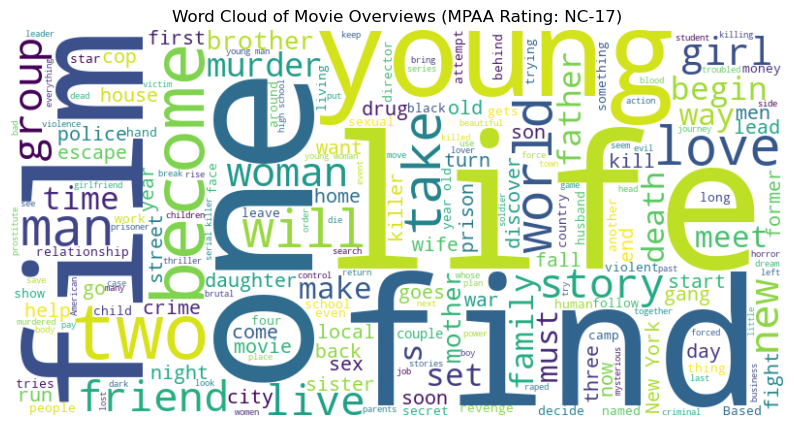

In [36]:
##### OVERVIEW BY MPAA RATING #####

# Define a function to generate word clouds for each mpaaRating category
def generate_word_cloud_by_rating(mpaa_rating):
    # Filter movies by mpaaRating
    movies_with_rating = movies_df[movies_df['mpaaRating'] == mpaa_rating]
    # Combine overviews into a single string
    all_overviews = ' '.join(movies_with_rating['overview'].dropna())
    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_overviews)
    # Plot the word cloud
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud of Movie Overviews (MPAA Rating: {mpaa_rating})')
    plt.axis('off')
    plt.show()

# List of desired MPAA ratings
desired_ratings = ['G', 'PG', 'PG-13', 'R', 'NC-17']

# Generate word clouds for each desired mpaaRating category
for mpaa_rating in desired_ratings:
    generate_word_cloud_by_rating(mpaa_rating)

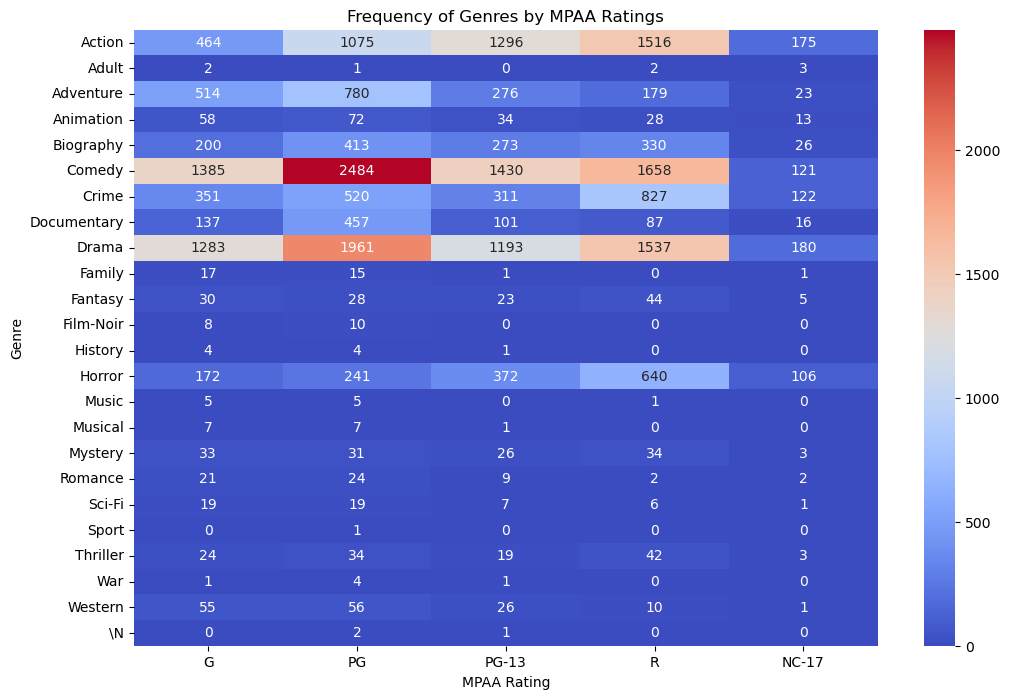

In [37]:
# Create a new dataframe to handle multiple genres
genres_df = movies_df['genres'].str.split(',', expand=True)

# Add the 'title' column to genres_df
genres_df['imdbID'] = movies_df['imdbID']
genres_df['title'] = movies_df['title']

# Perform the melt operation on genres_df
genres_long = genres_df.melt(value_name='genre').dropna()

# Merge the genres_long DataFrame with movies_df based on the index
merged_df = genres_long.merge(movies_df[['mpaaRating']], left_index=True, right_index=True)

# Create a pivot table to get counts of each combination of genre and MPAA rating
pivot_table = merged_df.pivot_table(index='genre', columns='mpaaRating', aggfunc='size', fill_value=0)

# Filter pivot_table to include only desired MPAA ratings
desired_ratings = ['G', 'PG', 'PG-13', 'R', 'NC-17']
filtered_pivot_table = pivot_table[desired_ratings]


# Plot heatmap for the correlation between genres and MPAA ratings
plt.figure(figsize=(12, 8))
sns.heatmap(filtered_pivot_table, cmap='coolwarm', annot=True, fmt='g')
plt.title('Frequency of Genres by MPAA Ratings')
plt.xlabel('MPAA Rating')
plt.ylabel('Genre')
plt.show()


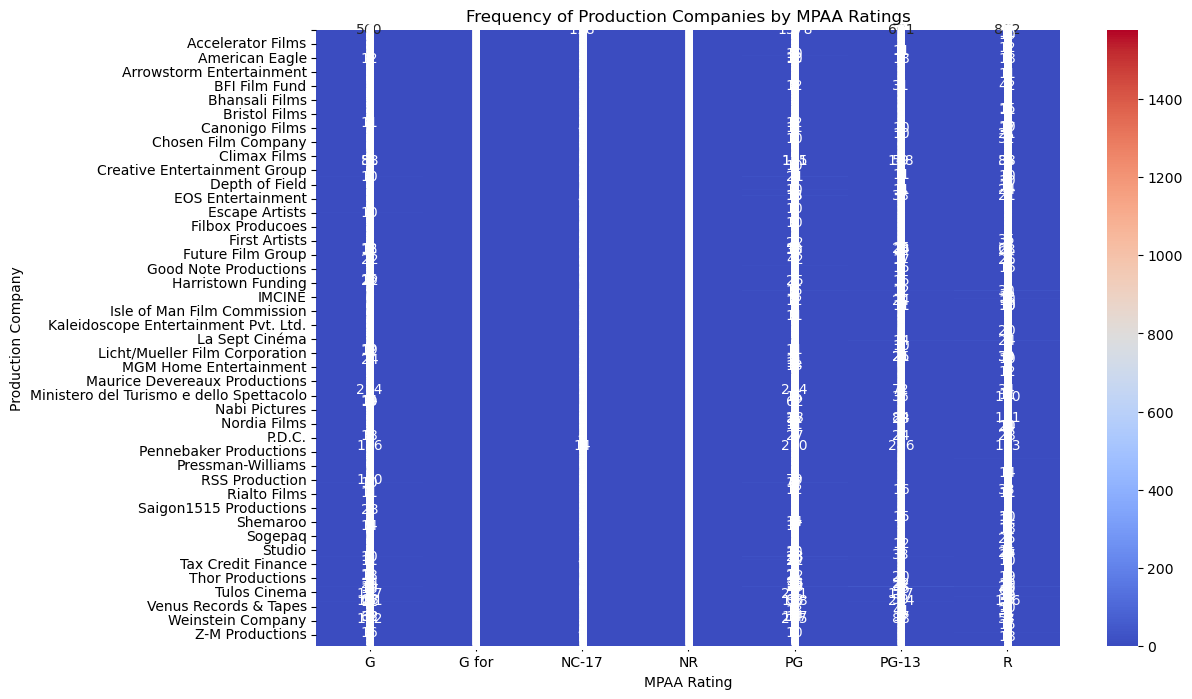

In [38]:
# Split the production companies column
companies_df = movies_df['productionCompaniesNames'].str.split(',', expand=True)

# Add the 'imdbID' column to companies_df
companies_df['imdbID'] = movies_df['imdbID']
companies_df['title'] = movies_df['title']

# Perform the melt operation on companies_df
companies_long = companies_df.melt(id_vars='imdbID', value_name='productionCompaniesNames').dropna()

# Merge the genres_long DataFrame with movies_df based on the index
merged_df = companies_long.merge(movies_df[['mpaaRating']], left_index=True, right_index=True)

# Create a pivot table to get counts of each combination of production company and MPAA rating
pivot_table = merged_df.pivot_table(index='productionCompaniesNames', columns='mpaaRating', aggfunc='size', fill_value=0)

# Plot heatmap for the correlation between production companies and MPAA ratings
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap='coolwarm', annot=True, fmt='g')
plt.title('Frequency of Production Companies by MPAA Ratings')
plt.xlabel('MPAA Rating')
plt.ylabel('Production Company')
plt.show()

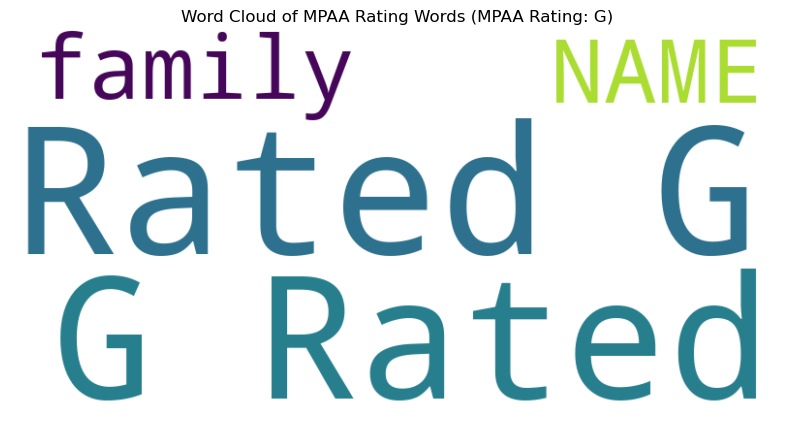

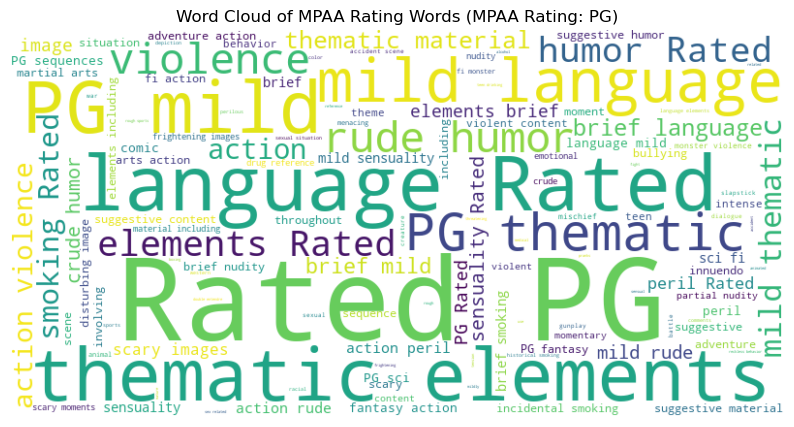

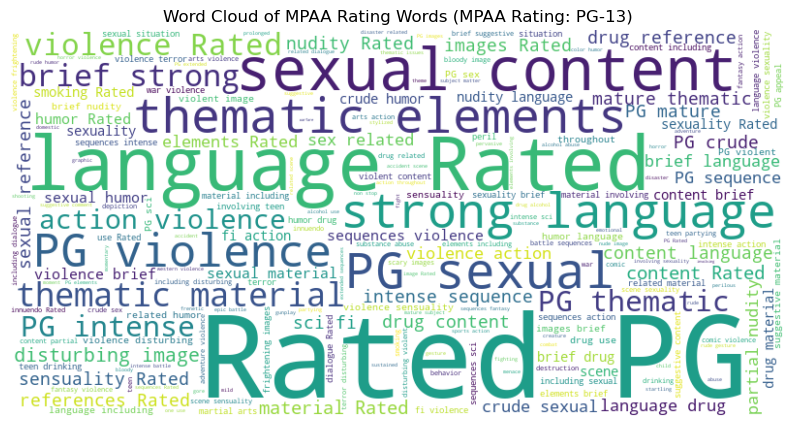

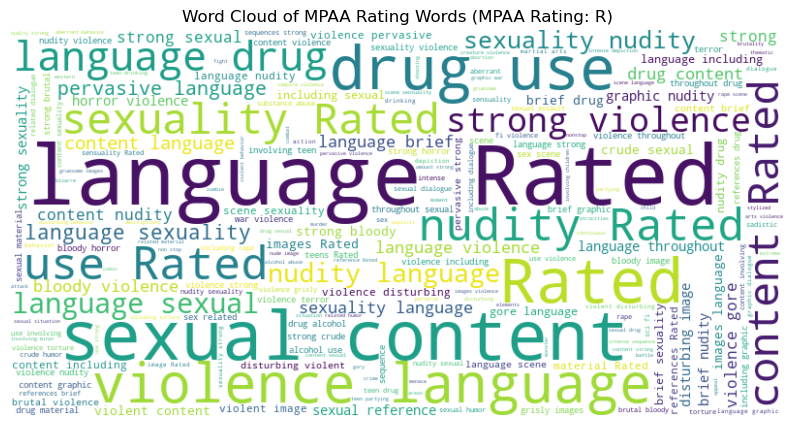

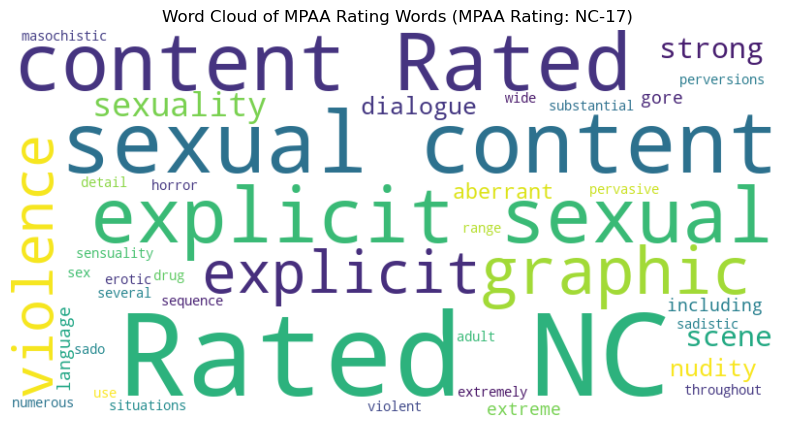

In [39]:
def generate_word_cloud_by_rating(mpaa_rating):
    # Filter movies by mpaaRating and non-empty mpaaRatingWords
    movies_with_rating = movies_df[(movies_df['mpaaRating'] == mpaa_rating) & (movies_df['mpaaRatingWords'] != "OOnan")]
    if not movies_with_rating.empty:
        # Flatten the list of mpaaRatingWords
        all_words = [word for sublist in movies_with_rating['mpaaRatingWords'] for word in sublist]
        # Combine mpaaRatingWords into a single string
        all_words_str = ' '.join(all_words)
        # Generate word cloud
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words_str)
        # Plot the word cloud
        plt.figure(figsize=(10, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f'Word Cloud of MPAA Rating Words (MPAA Rating: {mpaa_rating})')
        plt.axis('off')
        plt.show()

# List of desired MPAA ratings
desired_ratings = ['G', 'PG', 'PG-13', 'R', 'NC-17']

# Generate word clouds for each desired mpaaRating category
for mpaa_rating in desired_ratings:
    generate_word_cloud_by_rating(mpaa_rating)

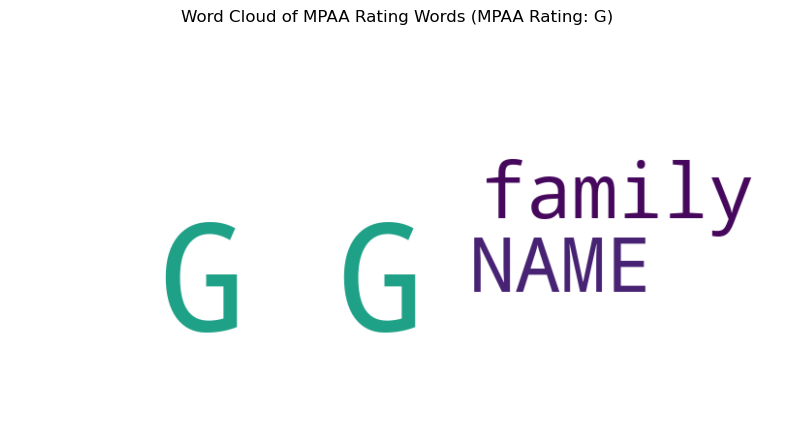

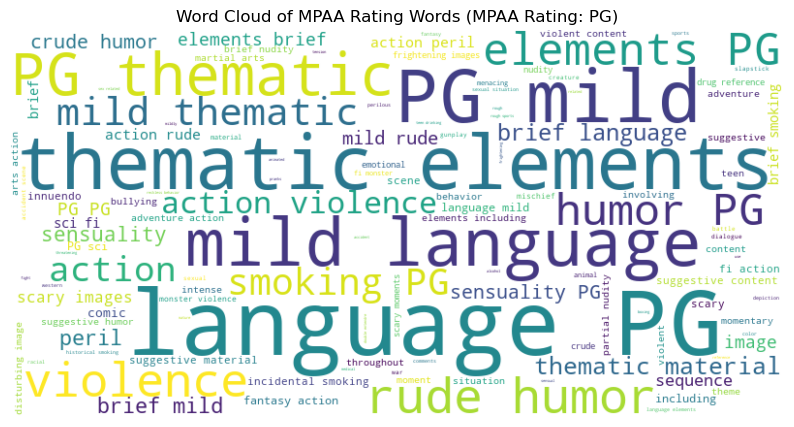

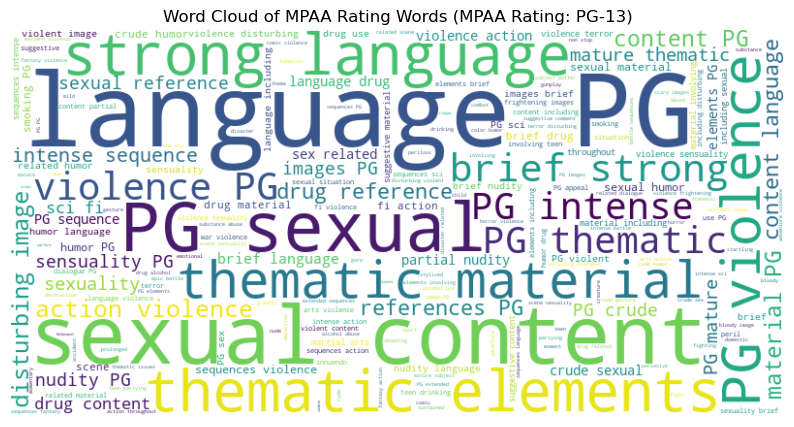

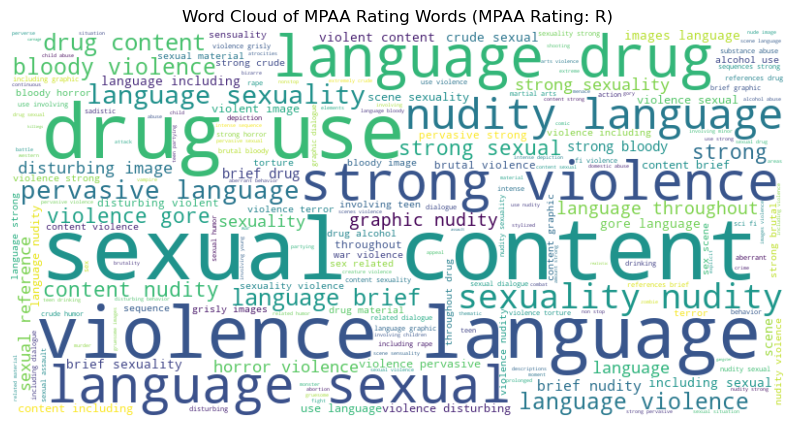

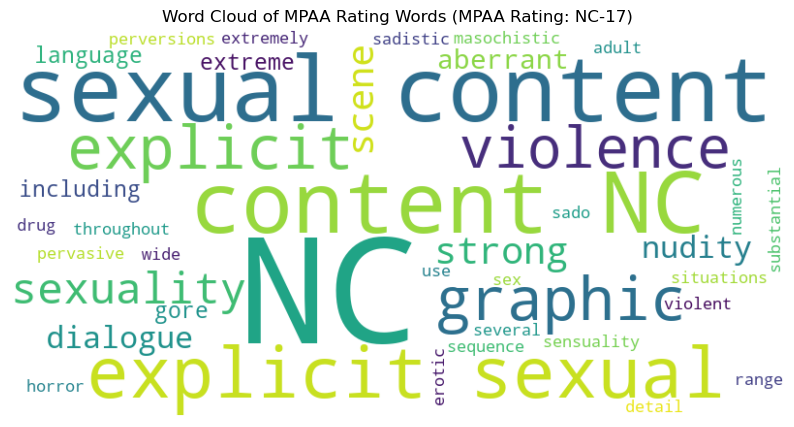

In [40]:
def generate_word_cloud_by_rating(mpaa_rating):
    # Filter movies by mpaaRating and non-empty mpaaRatingWords
    movies_with_rating = movies_df[(movies_df['mpaaRating'] == mpaa_rating) & (movies_df['mpaaRatingWords'] != "OOnan")]
    if not movies_with_rating.empty:
        # Flatten the list of mpaaRatingWords and remove the word 'Rated'
        all_words = [word for sublist in movies_with_rating['mpaaRatingWords'] for word in sublist if word != 'Rated']
        # Combine mpaaRatingWords into a single string
        all_words_str = ' '.join(all_words)
        # Generate word cloud
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words_str)
        # Plot the word cloud
        plt.figure(figsize=(10, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f'Word Cloud of MPAA Rating Words (MPAA Rating: {mpaa_rating})')
        plt.axis('off')
        plt.show()

# List of desired MPAA ratings
desired_ratings = ['G', 'PG', 'PG-13', 'R', 'NC-17']

# Generate word clouds for each desired mpaaRating category
for mpaa_rating in desired_ratings:
    generate_word_cloud_by_rating(mpaa_rating)

In [41]:
######################################################## MODEL BUILDING ########################################################
#### RANDOM FOREST MODEL 1
from sklearn.model_selection import train_test_split

# Prepare the dataset
features = ['sex_code', 'violence_code', 'profanity_code', 'drug_code', 'intense_code']
X = movies_df[features]
y = movies_df['mpaaRating']

# Drop rows with missing values
X.dropna(inplace=True)
y.dropna(inplace=True)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Train the random forest model
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

# Predict MPAA ratings for the testing set
y_pred = rf_model.predict(X_test)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

C:\Users\glory\AppData\Local\Temp\ipykernel_5392\3326199335.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.dropna(inplace=True)


Accuracy: 0.736490357074661


In [42]:
# Prepare the input data for "Shrek 2"
shrek_2_features = movies_df.loc[movies_df['title'] == 'Shrek 2', features]

# Predict the MPAA rating for "Shrek 2"
shrek_2_rating = rf_model.predict(shrek_2_features)

# Print the predicted MPAA rating for "Shrek 2"
print("Predicted MPAA rating for Shrek 2:", shrek_2_rating[0])

Predicted MPAA rating for Shrek 2: PG


In [43]:
##### RANDOM FOREST MODEL 2: Include genres
# Define the original features
original_features = ['sex_code', 'violence_code', 'profanity_code', 'drug_code', 'intense_code']

# Step 1: Identify all unique genres
all_genres = set()
for genres_list in movies_df['genres']:
    if genres_list is not None:
        all_genres.update(genres_list.split(','))

# Step 2: Create binary variables for each genre
for genre in all_genres:
    movies_df[genre] = movies_df['genres'].apply(lambda x: 1 if x is not None and genre in x else 0)

# Step 3: Concatenate binary genre variables with original features
features_with_genres = original_features + list(all_genres)

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(movies_df[features_with_genres], movies_df['mpaaRating'], test_size=0.2, random_state=42)

# Step 5: Train a new random forest model
rf_model_with_genres = RandomForestClassifier(random_state=42)
rf_model_with_genres.fit(X_train, y_train)

# Step 6: Predict MPAA ratings for the testing set
y_pred = rf_model_with_genres.predict(X_test)

# Step 7: Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7105212908153523


In [44]:
# Extract features for Shrek 2
shrek_2_features = movies_df[movies_df['title'] == 'Shrek 2'][features_with_genres]

# Predict the rating for Shrek 2
shrek_2_rating = rf_model_with_genres.predict(shrek_2_features)

print("Predicted rating for Shrek 2:", shrek_2_rating)

Predicted rating for Shrek 2: ['PG']


In [45]:
##### RANDOM FOREST MODEL 3: Exclude genres, include runtime
# Define features including runtime
features_with_runtime = original_features + ['runtime(mins.)']

# Split the dataset into training and testing sets with runtime
X_train_runtime, X_test_runtime, y_train_runtime, y_test_runtime = train_test_split(movies_df[features_with_runtime], movies_df['mpaaRating'], test_size=0.2, random_state=42)

# Drop samples with missing values from both features and target
X_train_runtime_dropped = X_train_runtime.dropna()
y_train_runtime_dropped = y_train_runtime[X_train_runtime_dropped.index]

# Train a new random forest model with runtime and dropped missing values
rf_model_with_runtime_dropped = RandomForestClassifier(random_state = 42)
rf_model_with_runtime_dropped.fit(X_train_runtime_dropped, y_train_runtime_dropped)

# Predict MPAA ratings for the testing set with runtime
y_pred_runtime_dropped = rf_model_with_runtime_dropped.predict(X_test_runtime)

# Evaluate the model's accuracy with runtime and dropped missing values
accuracy_runtime_dropped = accuracy_score(y_test_runtime, y_pred_runtime_dropped)
print("Accuracy (Model with runtime and dropped missing values):", accuracy_runtime_dropped)


Accuracy (Model with runtime and dropped missing values): 0.7004009929348863


In [46]:
#shrek_features = {
#    'sex_code': 2.0,          # Provide the value for sex_code
#    'violence_code': 2.0,     # Provide the value for violence_code
#    'profanity_code': 2.0,    # Provide the value for profanity_code
#    'drug_code': 2.0,         # Provide the value for drug_code
#    'intense_code': 2.0,      # Provide the value for intense_code
#    'runtime(mins.)': 93.0,   # Provide the value for runtime
#}

# Convert the feature dictionary to a DataFrame
#shrek_df = pd.DataFrame([shrek_features])

# Predict MPAA rating for Shrek
#shrek_rating = rf_model_with_runtime.predict(shrek_df)

#print("Predicted MPAA rating for Shrek:", shrek_rating)

In [47]:
######################################################## MODEL BUILDING ########################################################
#### DECISION TREES MODEL 1
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# Define the features
features = ['sex_code', 'violence_code', 'profanity_code', 'drug_code', 'intense_code']

# Prepare the dataset
X = movies_df[features]
y = movies_df['mpaaRating']

# Drop rows with missing values
X.dropna(inplace=True)
y.dropna(inplace=True)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the decision tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict MPAA ratings for the testing set
y_pred = dt_model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of the decision tree model:", accuracy)

# Predict MPAA rating for Shrek 2
shrek2_features = {
    'sex_code': 2.0,          # Provide the value for sex_code
    'violence_code': 2.0,     # Provide the value for violence_code
    'profanity_code': 2.0,    # Provide the value for profanity_code
    'drug_code': 2.0,         # Provide the value for drug_code
    'intense_code': 2.0,      # Provide the value for intense_code
}

# Convert the feature dictionary to a DataFrame
shrek2_df = pd.DataFrame([shrek2_features])

# Predict MPAA rating for Shrek 2
shrek2_rating = dt_model.predict(shrek2_df)

print("Predicted MPAA rating for Shrek 2:", shrek2_rating)

Accuracy of the decision tree model: 0.7341989688753103
Predicted MPAA rating for Shrek 2: ['PG']


C:\Users\glory\AppData\Local\Temp\ipykernel_5392\445633409.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.dropna(inplace=True)
